In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.stats import norm
import seaborn as sns
from scipy.stats import ttest_ind

# Solution for (a)

### Compute the calibration of a normal-based CI for the mean under lognormal data.

We define the normal‐based CI for the mean as

$
\bigl[\,
\bar y + Q_{\alpha/2}\,\mathrm{SE}_{\bar y}
\;,\;
\bar y + Q_{1-\alpha/2}\,\mathrm{SE}_{\bar y}
\bigr]
$

where
$
[
\bar y = \frac{1}{n}\sum_{i=1}^n y_i,
\quad
\mathrm{SE}_{\bar y} = \frac{\mathrm{SD}_{y}}{\sqrt{n}},
\quad
\mathrm{SD}_{y} = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (y_i - \bar y)^2},
]
$

and $Q_p$ is the $p^{th}$ quantile of the standard normal.


In [2]:
def ci_mean(y, alpha):
    mean = np.mean(y)
    se = np.std(y, ddof=1) / np.sqrt(len(y))  # standard error
    z_low, z_high = norm.ppf([alpha/2, 1 - alpha/2])  # normal quantiles
    return mean + np.array([z_low, z_high]) * se  # the two CI end-points

Our model for generating data is $𝑦_𝑖 ∼ LogNormal(𝜇, 𝜎)$ for 𝑖 ∈ {1, ... , 𝑛}.

We specify a grid of values for the parameters 𝜇 and 𝜎, as well as the sample sizes 𝑛 for the simulations.

In [ ]:
ns = [10, 100, 1000]
mus = [-1, 0, 1]
sigmas = [0.1, 1, 2]

We also want to calculate the coverage of the CI for different confidence levels 1 − 𝛼.

In [ ]:
alphas = [0.5, 1/3, 0.2, 0.1]

The precision of our results will be determined by how many simulations we conduct for each combination of the parameter values.

In [ ]:
n_sim = 10_000

Finally, we can loop over all our simulation configurations, simulate data n_sim times, calculate the CI for different 𝛼, and check whether the CI covers the population mean, which is defined as $exp(𝜇 + 𝜎^2/2)$ for lognormal data.

In [3]:
np.random.seed(394)

records = []
for n, mu, sigma in product(ns, mus, sigmas):
    true_mean = np.exp(mu + sigma**2 / 2)
    counts = np.zeros(len(alphas))

    for _ in range(n_sim):
        y = np.random.lognormal(mean=mu, sigma=sigma, size=n)  # draw a sample y of size n
        for i, alpha in enumerate(alphas):
            low, high = ci_mean(y, alpha)       # for each alpha, form a normal‐based CI via ci_mean
            counts[i] += (low < true_mean) & (true_mean < high)  # increment a counter if that CI covers the true mean

    coverage = counts / n_sim * 100  # convert counts to percentage coverage
    for alpha, cov in zip(alphas, coverage):
        records.append({
            'n': n,
            'mu': mu,
            'sigma': sigma,
            'ci_level': int(round((1-alpha)*100)),
            'coverage': cov
        })

df = pd.DataFrame(records)

Now we can analyze the results. Here we simply plot the nominal vs actual coverage percentage for different simulation settings.

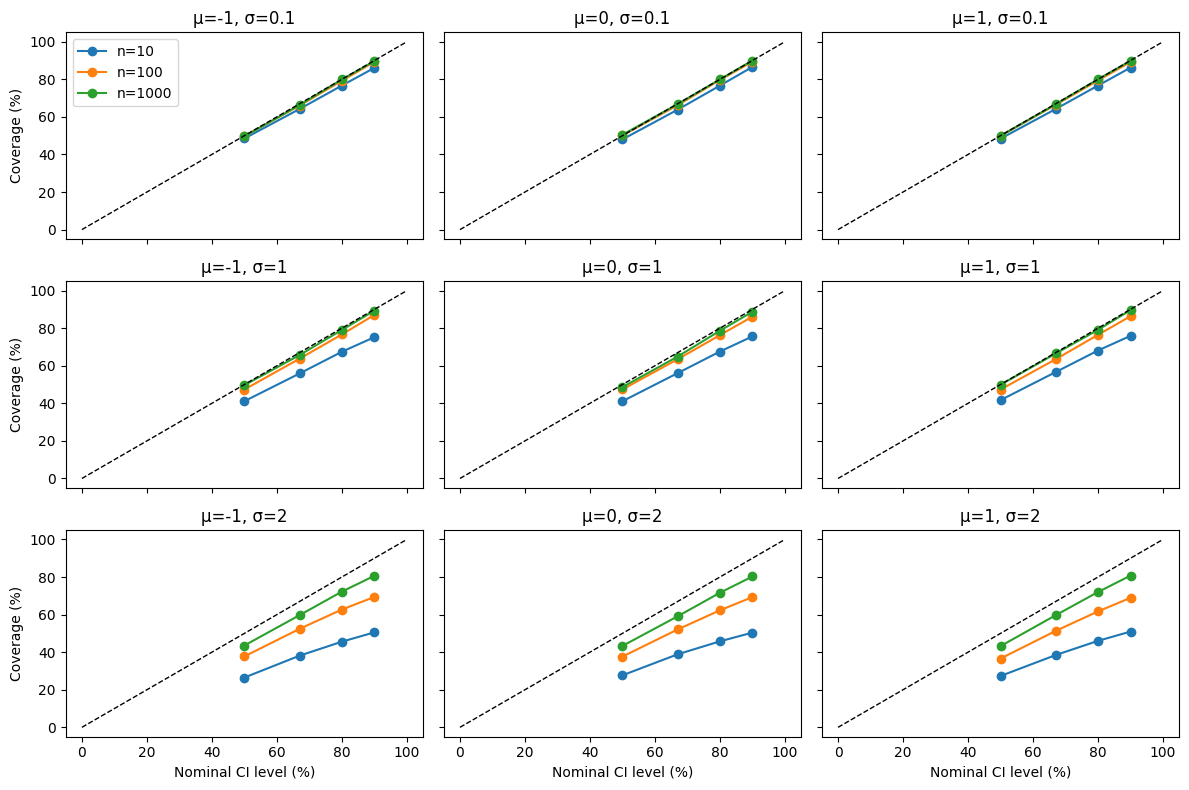

In [4]:
fig, axes = plt.subplots(len(sigmas), len(mus), figsize=(12, 8), sharex=True, sharey=True)
for i, sigma in enumerate(sigmas):
    for j, mu in enumerate(mus):
        ax = axes[i, j]
        sub = df[(df.sigma==sigma)&(df.mu==mu)]
        for n in ns:
            sd = sub[sub.n==n]
            ax.plot(sd.ci_level, sd.coverage, '-o', label=f'n={n}')
        ax.plot([0,100],[0,100],'k--', linewidth=1)
        ax.set_title(f'μ={mu}, σ={sigma}')
        if i==len(sigmas)-1:
            ax.set_xlabel('Nominal CI level (%)')
        if j==0:
            ax.set_ylabel('Coverage (%)')
        if i==0 and j==0:
            ax.legend()
plt.tight_layout()
plt.show()


- It is clear that the actual coverage of the normal-based confidence interval depends on the value of 𝜎 and the sample size 𝑛.

- Larger values of 𝜎 result in greater skewness in the data distribution, which reduces the accuracy of the normal approximation.

- In contrast, increasing the sample size improves the coverage due to the Central Limit Theorem.

# Solution for (b)

### Compute the p-curve for the t-test for unequal variances under a normal and log- normal scenario where the variances are (1) same or (2) different.

Our model for generating data under the normal scenario is

$𝑥_𝑖 ∼ Normal(𝜇, 𝜎_𝑥)$

$𝑦_𝑖 ∼ Normal(𝜇, 𝜎_𝑦)$, for $𝑖 ∈ {1,...,𝑛}$.

Under the lognormal scenario, the situation is a little bit more complex, since the expectation of a lognormal variable X depends on both parameters $𝜇_𝑥$ and $𝜎_𝑥$, as

$𝔼(𝑋) = exp(𝜇_𝑥 + 𝜎_𝑥^2/2)$.

To ensure that we sample data according to the null hypothesis that the population means are the same, we set $𝔼(𝑋) = 𝔼(𝑌 ) = exp(𝜇)$ and solve for $𝜇_𝑥$ and $𝜇_y$ , respectively.

$𝑥_𝑖∼LogNormal(𝜇_𝑥=𝜇− 𝜎_𝑥^2/2,𝜎_𝑥)$

$y_𝑖∼LogNormal(𝜇_y=𝜇− 𝜎_y^2/2,𝜎_y)$.

Under both models, the population variances are equal when $𝜎_𝑥 = 𝜎_𝑦$.

For the simulation we set 𝑛 = 50 and 𝜇 = 0, and vary $𝜎_𝑥$,
$𝜎_𝑦$ and the likelihood function (normal or lognormal).

In [5]:
n_sim = 10_000
n     = 50
mu    = 0
likelihoods = ['normal', 'lognormal']
sigmas = [0.1, 1, 2]

##  Welch’s *t*-test

Suppose you have two independent samples  
$
\{x_i\}_{i=1}^{n_1},\quad \{y_j\}_{j=1}^{n_2}
$

with unknown means ($\mu_x,\mu_y$) and (possibly) different variances \($\sigma_x^2,\sigma_y^2$).  

1. **Estimate the difference of means**  
   $
     \Delta \;=\;\bar x - \bar y,
     \qquad
     \bar x = \frac1{n_1}\sum_{i=1}^{n_1}x_i,\quad
     \bar y = \frac1{n_2}\sum_{j=1}^{n_2}y_j.
   $

2. **Compute the standard error**  
   $
     \mathrm{SE}(\Delta)
     = \sqrt{\frac{s_x^2}{n_1} \;+\;\frac{s_y^2}{n_2}},
     \quad
     s_x^2 = \frac{1}{n_1-1}\sum_{i=1}^{n_1}(x_i-\bar x)^2,\quad
     s_y^2 = \frac{1}{n_2-1}\sum_{j=1}^{n_2}(y_j-\bar y)^2.
   $

3. **Form the t–statistic**  
   $
     t
     = \frac{\bar x - \bar y}{\displaystyle\sqrt{\tfrac{s_x^2}{n_1} + \tfrac{s_y^2}{n_2}}}.
   $

4. **Approximate degrees of freedom** (Welch–Satterthwaite)  
   $
     \nu
     = \frac{\bigl(\tfrac{s_x^2}{n_1} + \tfrac{s_y^2}{n_2}\bigr)^{2}}
            {\frac{s_x^4}{n_1^2\,(n_1-1)} \;+\;\frac{s_y^4}{n_2^2\,(n_2-1)}}.
   $

5. **Two‐sided p-value**  
   $
     p = 2\bigl[1 - F_{t_\nu}\bigl(|t|\bigr)\bigr],
   $
   where ($F_{t_\nu}$) is the CDF of the Student-t distribution with ($\nu$) degrees of freedom.

  In most statistical packages you can just call a single function—e.g. in SciPy:


In [ ]:
from scipy.stats import ttest_ind
pval = ttest_ind(x, y, equal_var=False).pvalue

Once we define our simulation grid, we can simulate the data, compute and store the p-value
of the Welch t-test for unequal variances.

In [6]:
# the parameter grid

grid = pd.DataFrame(
    product(range(n_sim), likelihoods, sigmas, sigmas),
    columns=['sim', 'lik', 'sigma_x', 'sigma_y']
)
grid['n'] = n
grid['mu'] = mu
grid['p_value'] = np.nan

# run simulations

for idx, row in grid.iterrows():
    if row.lik == 'normal':
        x = np.random.normal(row.mu, row.sigma_x, row.n)
        y = np.random.normal(row.mu, row.sigma_y, row.n)
    else:
        x = np.random.lognormal(mean=row.mu - row.sigma_x**2/2, sigma=row.sigma_x, size=row.n)
        y = np.random.lognormal(mean=row.mu - row.sigma_y**2/2, sigma=row.sigma_y, size=row.n)

    pval = ttest_ind(x, y, equal_var=False).pvalue
    grid.at[idx, 'p_value'] = pval


In [7]:
def plot_hist(data, title):
    g = sns.FacetGrid(data, row='sigma_x', col='sigma_y',
                      margin_titles=True, sharey=False)
    g.map_dataframe(sns.histplot, x='p_value', stat='density',
                    binwidth=0.05, color='lightgray', edgecolor='black')
    for ax in g.axes.flat:
        ax.axhline(1, ls='--', color='black')  # uniform(0,1) density reference
    g.set_axis_labels('p-value', 'Density')
    g.fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

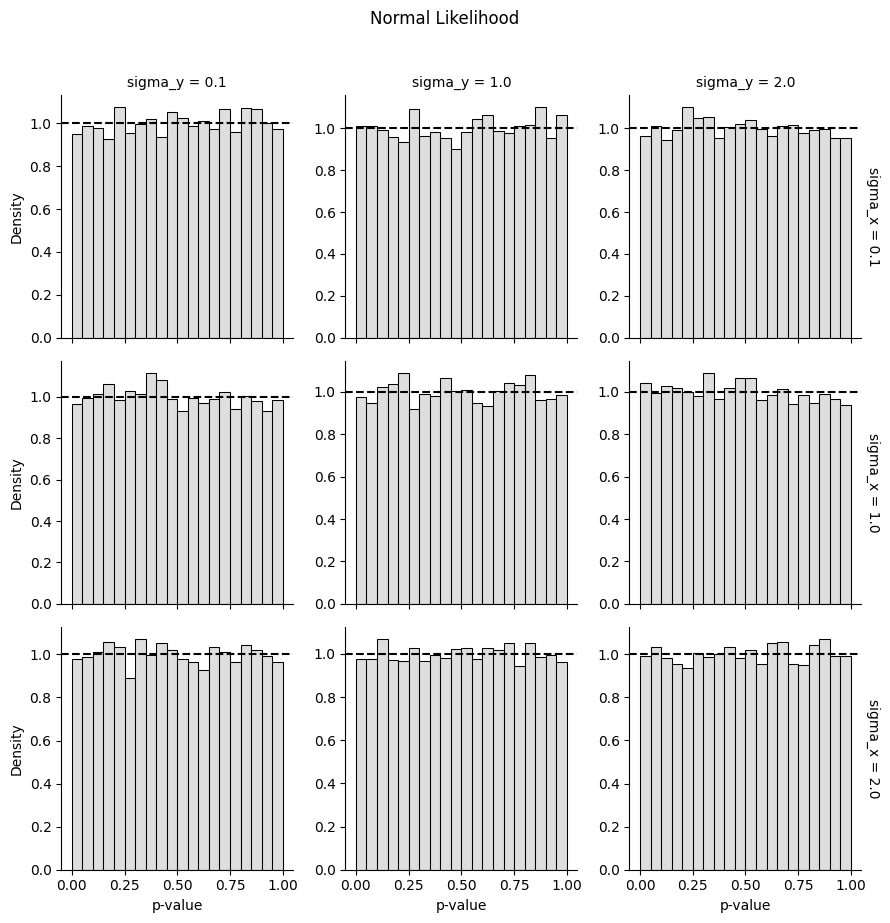

In [8]:
# 5. Display only the Normal-likelihood p-curve
plot_hist(grid[grid.lik == 'normal'], title='Normal Likelihood')

The Welch t-test is well calibrated across different values of $𝜎_𝑥$ and $𝜎_𝑦$ as the simulated p-values from the null model are approximately uniform.

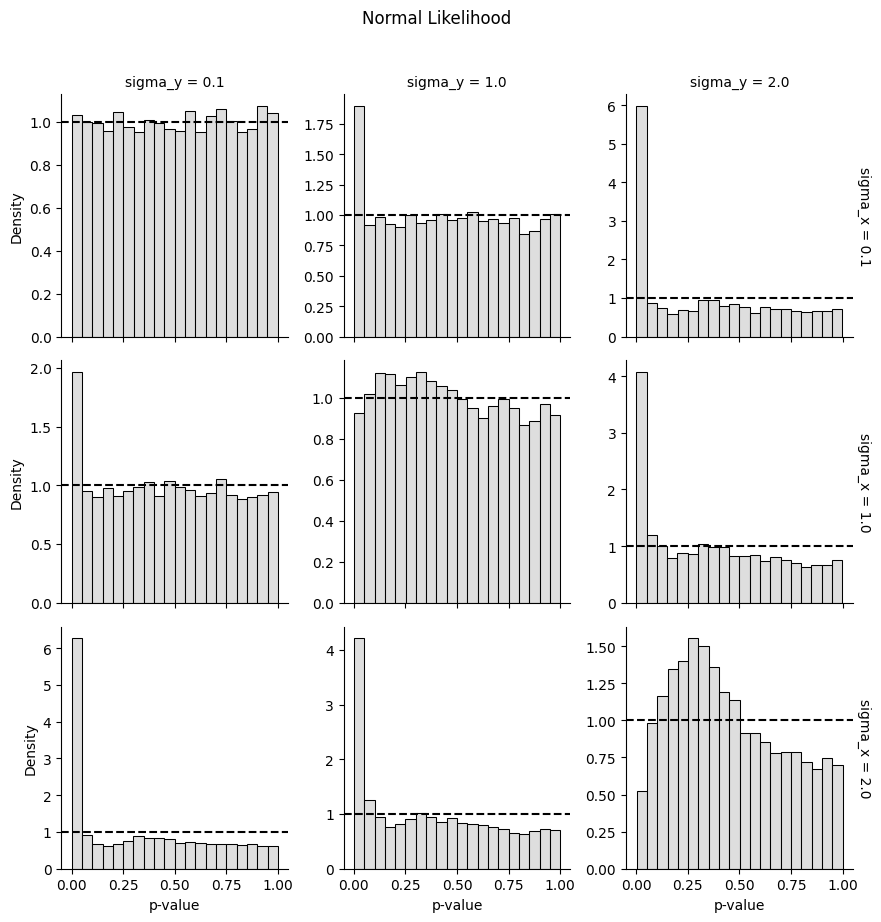

In [9]:
plot_hist(grid[grid.lik == 'lognormal'], title='LogNormal Likelihood')

The Welch t-test is not well calibrated for lognormal data.
- The degree of miscalibration depends on the values of $𝜎_𝑥$ and $𝜎_y$.
- When $𝜎_𝑥$ ≠ $𝜎_y$, the test seems to have many false positives, as indicated by the spike of p-values near zero.
- When $𝜎_𝑥$ = $𝜎_y$, the miscalibration is less pronounced, especially for small values. This is because small values of 𝜎 lead to small skewness, which makes the data closer to the normal distribution.